In [22]:
#!pip install scikit-learn pandas matplotlib seaborn graphviz

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, RepeatedStratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_auc_score, roc_curve, classification_report
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

کاوش داده‌های اولیه (Exploratory Data Analysis - EDA)

In [21]:
df = pd.read_csv('data.csv')  
df.shape, df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


آماده‌سازی داده‌ها

In [8]:
# حذف ستون اضافی
df.drop(columns=['Unnamed: 32'], inplace=True)

# تغییر نام ستون هدف
df.rename(columns={'diagnosis': 'target'}, inplace=True)

# توزیع کلاس‌ها
print(df['target'].value_counts(normalize=True))

# چک مقادیر Null
print(df.isnull().sum())



target
B    0.627417
M    0.372583
Name: proportion, dtype: float64
id                         0
target                     0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtyp

نمودارها

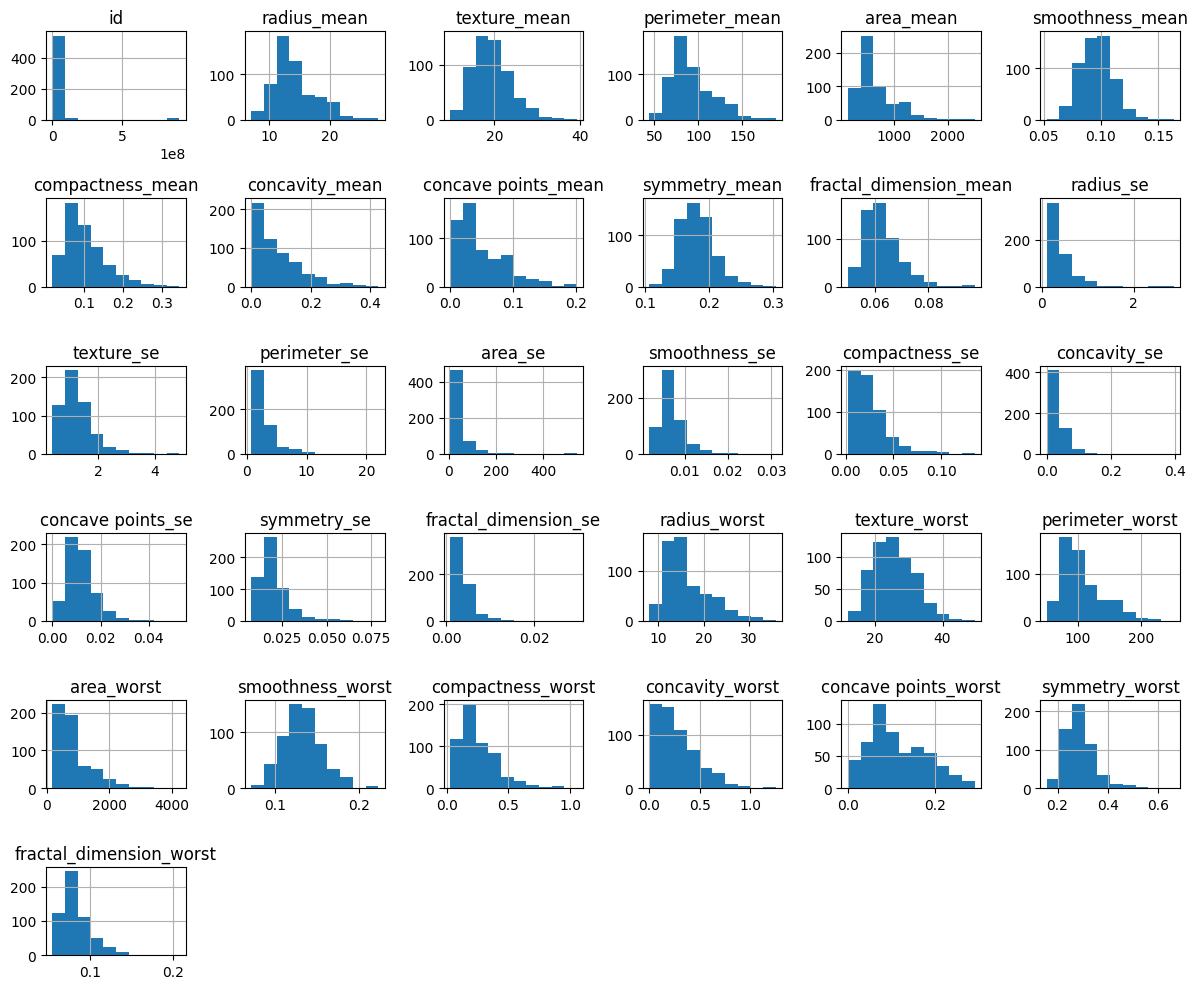

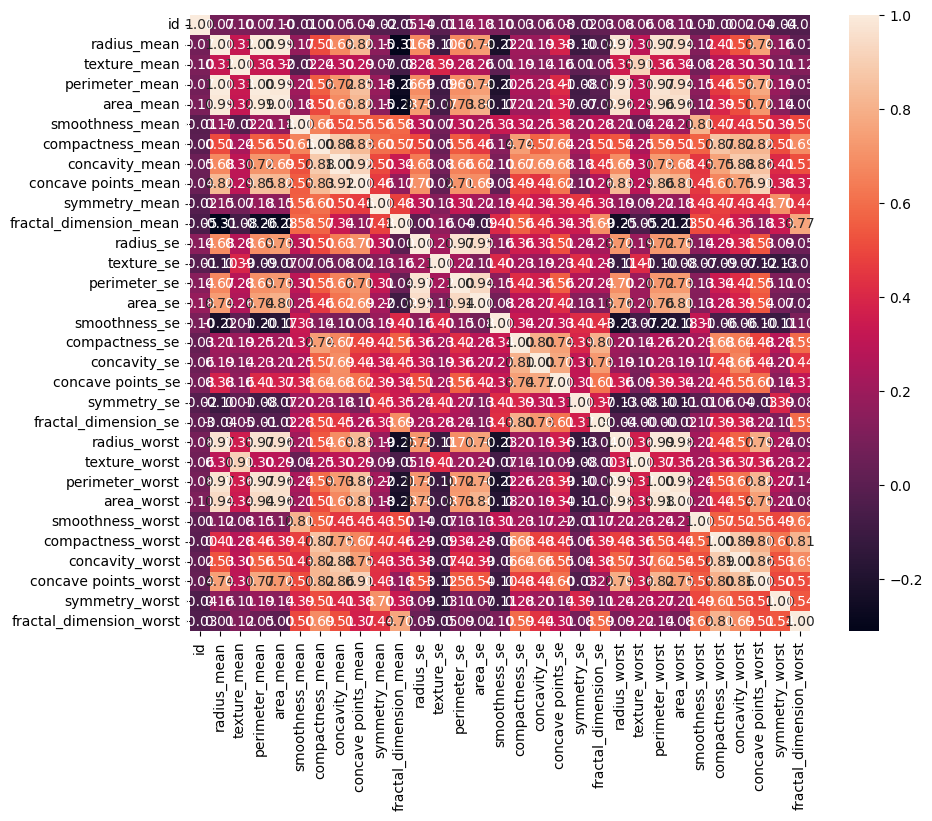

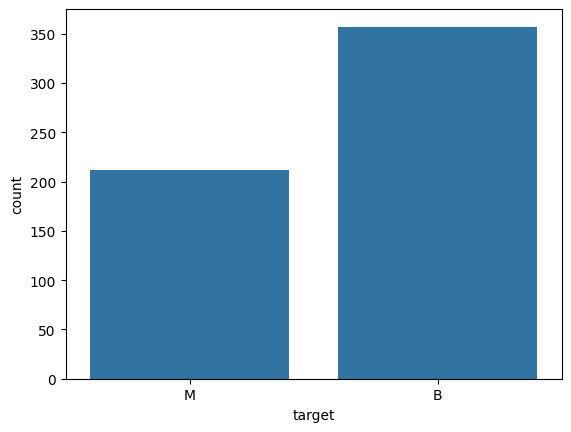

In [10]:
# --- Histogram ---
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

# --- Heatmap only numeric columns ---
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=['number'])  # انتخاب ستون‌های عددی
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f")
plt.show()

# --- Class Distribution ---
sns.countplot(x='target', data=df)
plt.show()


آماده‌سازی نهایی داده‌ها (Data Preparation) 
جدا کردن ویژگی‌ها از متغیر هدف و مدیریت داده‌های گم‌شده (Missing Data)
تبدیل متغیرهای دسته‌بندی‌شده (Categorical)


In [11]:
# جدا کردن X و y
X = df.drop(columns=['target'])
y = df['target']


num_cols = X.select_dtypes(include=['int64','float64']).columns
imputer = SimpleImputer(strategy='median')
X[num_cols] = imputer.fit_transform(X[num_cols])


cat_cols = X.select_dtypes(include=['object','category']).columns
if len(cat_cols) > 0:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)


آموزش مدل درخت تصمیم

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           B       0.93      0.94      0.94        72
           M       0.90      0.88      0.89        42

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114



k-fold cross-validation

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

scores = cross_validate(clf, X, y, scoring=scoring, cv=cv, return_train_score=False)
for key in scores:
    print(key, scores[key].mean(), scores[key].std())


fit_time 0.011232948303222657 0.002084267270854732
score_time 0.010398149490356445 0.0021709595658579444
test_accuracy 0.9209594783418724 0.017404566054317897
test_precision_macro 0.9188477932736918 0.021286119098937514
test_recall_macro 0.9141235006940869 0.020283325464152326
test_f1_macro 0.9151222320834582 0.018802630111442033


تکرار 10 اجرا + k-fold

In [14]:
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
scores = cross_validate(clf, X, y, scoring=scoring, cv=rskf)
# توجه: cross_validate با Repeated خروجی طولانی خواهد داد؛ محاسبه میانگین:
import numpy as np
print("accuracy mean", np.mean(scores['test_accuracy']), "std", np.std(scores['test_accuracy']))
print("f1 mean", np.mean(scores['test_f1_macro']), "std", np.std(scores['test_f1_macro']))


accuracy mean 0.9288076385654402 std 0.022767769632215957
f1 mean 0.9238654684189147 std 0.02428399674093189


GridSearch برای بهینه‌سازی پارامترها

In [15]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 8, 12],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
gs = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
gs.fit(X, y)
gs.best_params_, gs.best_score_
best_clf = gs.best_estimator_


رسم درخت

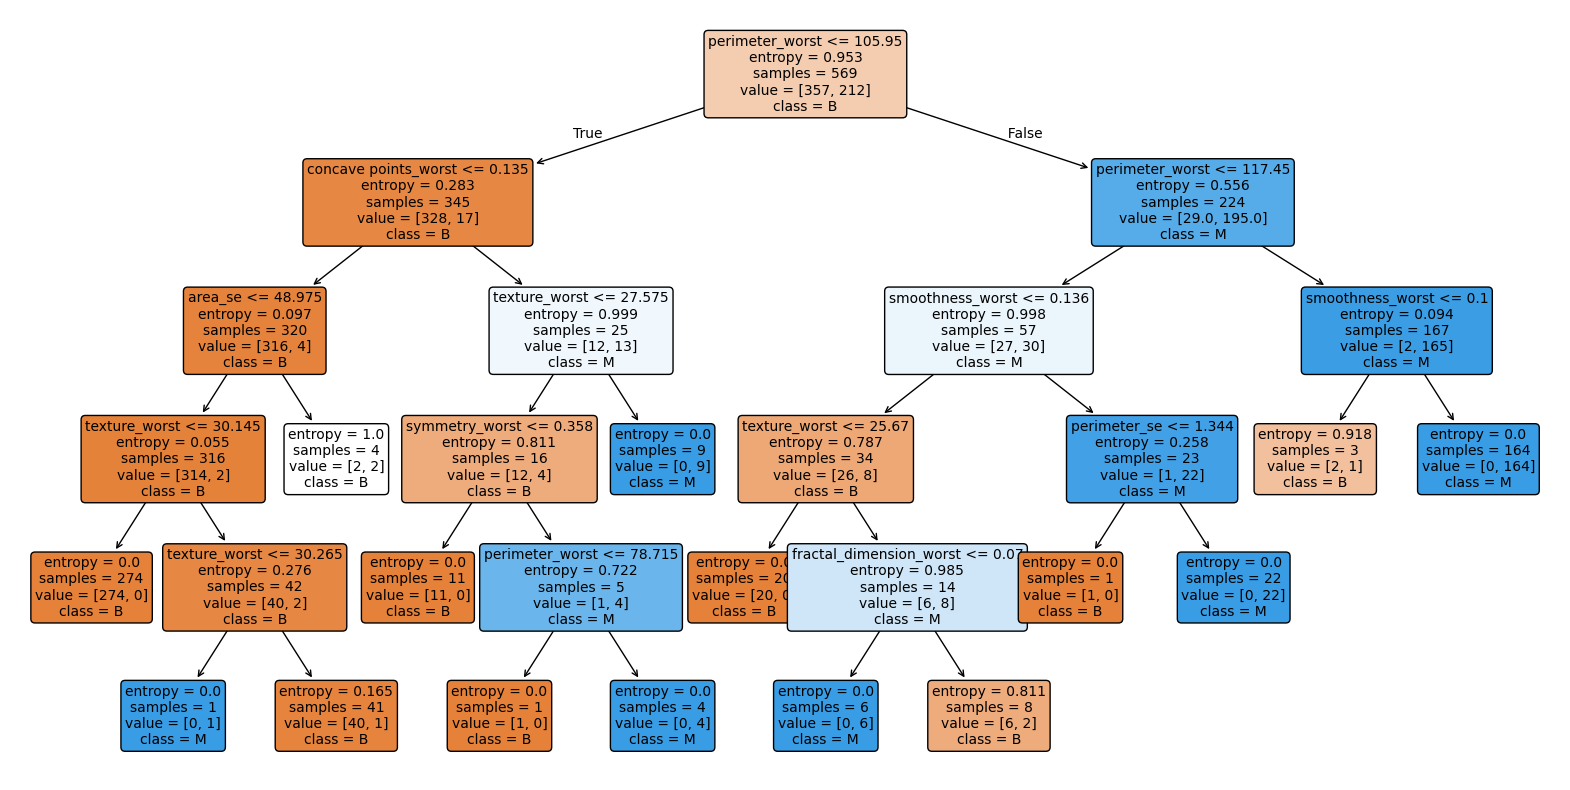

|--- perimeter_worst <= 105.95
|   |--- concave points_worst <= 0.14
|   |   |--- area_se <= 48.98
|   |   |   |--- texture_worst <= 30.15
|   |   |   |   |--- class: B
|   |   |   |--- texture_worst >  30.15
|   |   |   |   |--- texture_worst <= 30.27
|   |   |   |   |   |--- class: M
|   |   |   |   |--- texture_worst >  30.27
|   |   |   |   |   |--- class: B
|   |   |--- area_se >  48.98
|   |   |   |--- class: B
|   |--- concave points_worst >  0.14
|   |   |--- texture_worst <= 27.58
|   |   |   |--- symmetry_worst <= 0.36
|   |   |   |   |--- class: B
|   |   |   |--- symmetry_worst >  0.36
|   |   |   |   |--- perimeter_worst <= 78.72
|   |   |   |   |   |--- class: B
|   |   |   |   |--- perimeter_worst >  78.72
|   |   |   |   |   |--- class: M
|   |   |--- texture_worst >  27.58
|   |   |   |--- class: M
|--- perimeter_worst >  105.95
|   |--- perimeter_worst <= 117.45
|   |   |--- smoothness_worst <= 0.14
|   |   |   |--- texture_worst <= 25.67
|   |   |   |   |--- class: B

In [16]:
plt.figure(figsize=(20,10))
plot_tree(best_clf, feature_names=X.columns, class_names=[str(c) for c in np.unique(y)], filled=True, rounded=True, fontsize=10)
plt.show()

# یا متنی
r = export_text(best_clf, feature_names=list(X.columns))
print(r)


              precision    recall  f1-score   support

           B       0.99      1.00      0.99        72
           M       1.00      0.98      0.99        42

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



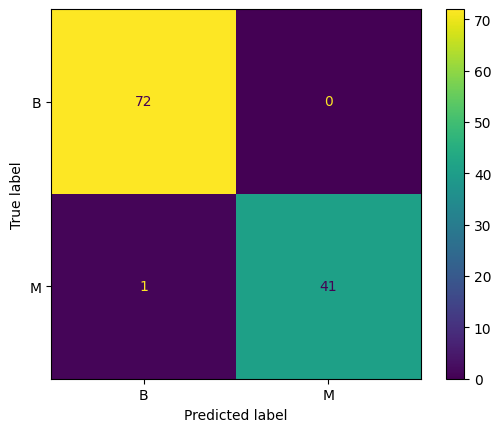

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay
y_pred = best_clf.predict(X_test)
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_estimator(best_clf, X_test, y_test)
plt.show()


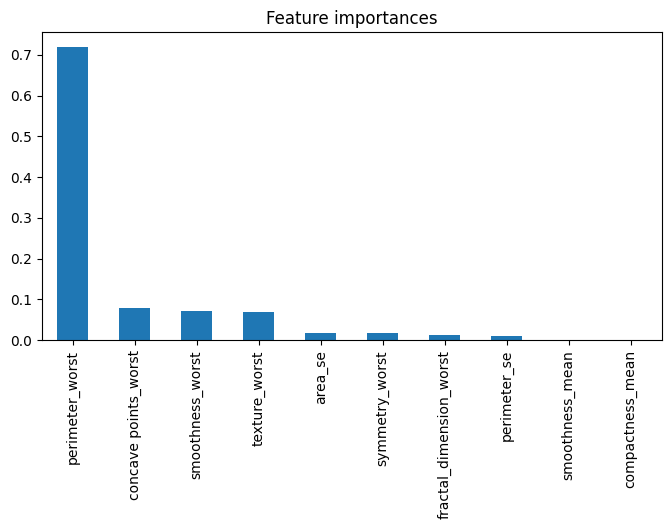

In [18]:
fi = pd.Series(best_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
fi.head(10).plot.bar(figsize=(8,4))
plt.title("Feature importances")
plt.show()
